In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from pathlib import Path

In [2]:
# Prep to read pre-processed data

CONDITIONS = {
    'black_white': {
        'base': 'data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02',
    },
    'blue_yellow': {
        'base': 'data/blueyellow_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01',
    },
    'red_green': {
        'base': 'data/redgreen_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01', 
    },
}

N_RUNS          = 5    # run-1 〜 run-5
N_CLASS         = 32   # 32 keys
N_PER_CLASS     = 2    # 2 trials per class
FS              = 250  # Sampling rate (Hz)

print("Paths defined.")

Paths defined.


In [3]:
# Read data function <= change later

def load_condition(base_path, n_runs=5):
    """
    1条件分の eeg-trials と aux-trials を全run読み込んで結合する。

    Returns
    -------
    eeg    : np.ndarray, shape (n_trials_total, 8, 350)
             n_trials_total = n_runs × 64 試行
    aux    : np.ndarray, shape (n_trials_total, 3, 350)
             aux[:, 0, :] = 刺激符号 (337 or 338)
    labels : np.ndarray, shape (n_trials_total,)
             各試行の正解クラス (0〜31)
             data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux_2-per-class_run-1.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux_2-per-class_run-2.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux_2-per-class_run-3.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux_2-per-class_run-4.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux_2-per-class_run-5.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux-trials_2-per-class_run-1.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux-trials_2-per-class_run-2.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux-trials_2-per-class_run-3.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux-trials_2-per-class_run-4.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/aux-trials_2-per-class_run-5.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg_2-per-class_run-1.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg_2-per-class_run-2.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg_2-per-class_run-3.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg_2-per-class_run-4.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg_2-per-class_run-5.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg-trials_2-per-class_run-1.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg-trials_2-per-class_run-2.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg-trials_2-per-class_run-3.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg-trials_2-per-class_run-4.npy
data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02/eeg-trials_2-per-class_run-5.npy
    """
    
    base = Path(base_path)
    eeg_list, aux_list, label_list = [], [], []

    for run in range(1, n_runs + 1):
        eeg_path = base / f'eeg-trials_2-per-class_run-{run}.npy'
        aux_path = base / f'aux-trials_2-per-class_run-{run}.npy'

        if not eeg_path.exists():
            print(f"  [skip] {eeg_path.name} not found")
            continue

        eeg = np.load(eeg_path)  # (64, 8, 350)
        aux = np.load(aux_path)  # (64, 3, 350)

        # Labels: 2 tirals per class [0,0,1,1,...,31,31]
        labels = np.repeat(np.arange(N_CLASS), N_PER_CLASS)

        eeg_list.append(eeg)
        aux_list.append(aux)
        label_list.append(labels)
        print(f"  run-{run}: eeg={eeg.shape}, aux={aux.shape}")

    eeg_all    = np.concatenate(eeg_list,   axis=0)
    aux_all    = np.concatenate(aux_list,   axis=0)
    labels_all = np.concatenate(label_list, axis=0)

    print(f"  → Total: eeg={eeg_all.shape}, labels={labels_all.shape}\n")
    return eeg_all, aux_all, labels_all


print("Function defined.")

Function defined.


In [4]:
# Read data

data = {}

for cond_name, info in CONDITIONS.items():
    print(f"Loading: {cond_name}")
    eeg, aux, labels = load_condition(info['base'], n_runs=N_RUNS)
    data[cond_name] = {
        'eeg'   : eeg,    # (n_trials, 8, 350), Pass to CCA
        'aux'   : aux,    # (n_trials, 3, 350), use as template
        'labels': labels, # (n_trials,), lables
    }

print("All conditions loaded.")

Loading: black_white
  run-1: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-2: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-3: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-4: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-5: eeg=(64, 8, 350), aux=(64, 3, 350)
  → Total: eeg=(320, 8, 350), labels=(320,)

Loading: blue_yellow
  run-1: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-2: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-3: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-4: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-5: eeg=(64, 8, 350), aux=(64, 3, 350)
  → Total: eeg=(320, 8, 350), labels=(320,)

Loading: red_green
  run-1: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-2: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-3: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-4: eeg=(64, 8, 350), aux=(64, 3, 350)
  run-5: eeg=(64, 8, 350), aux=(64, 3, 350)
  → Total: eeg=(320, 8, 350), labels=(320,)

All conditions loaded.


In [5]:
# Check shape & value range
for cond_name, d in data.items():
    eeg    = d['eeg']
    labels = d['labels']
    print(f"--- {cond_name} ---")
    print(f"  eeg shape    : {eeg.shape}")          # expected val: (320, 8, 350) = 5runs×64
    print(f"  labels shape : {labels.shape}")       # expected val: (320,)
    print(f"  unique labels: {np.unique(labels)}")  # expected val: 0〜31
    print(f"  eeg min/max  : {eeg.min():.2f} / {eeg.max():.2f}")
    print()

--- black_white ---
  eeg shape    : (320, 8, 350)
  labels shape : (320,)
  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
  eeg min/max  : -61.32 / 190.23

--- blue_yellow ---
  eeg shape    : (320, 8, 350)
  labels shape : (320,)
  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
  eeg min/max  : -251.39 / 106.10

--- red_green ---
  eeg shape    : (320, 8, 350)
  labels shape : (320,)
  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
  eeg min/max  : -193.79 / 226.72



In [6]:
# Create stimuli template
# CCA ref signals
# ============================================================

def make_templates(aux_all, labels_all, n_class=32):
    """
    aux ch0 (337 or 338) → 0/1 にバイナリ化し、
    クラスごとに平均して参照テンプレートを作る。

    Returns
    -------
    templates : np.ndarray, shape (32, 350)
    """
    n_samples = aux_all.shape[2]
    templates = np.zeros((n_class, n_samples))

    for cls in range(n_class):
        idxs = np.where(labels_all == cls)[0]
        codes = [(aux_all[i, 0, :] > 337).astype(float) for i in idxs]
        templates[cls] = np.mean(codes, axis=0)

    return (templates > 0.5).astype(float)  # binarize


# add template to each condition
for cond_name, d in data.items():
    d['templates'] = make_templates(d['aux'], d['labels'])
    print(f"{cond_name}: templates shape = {d['templates'].shape}")  # (32, 350)

black_white: templates shape = (32, 350)
blue_yellow: templates shape = (32, 350)
red_green: templates shape = (32, 350)


In [7]:
# STEP 7: CCA Feature Extraction
# Calculate: each trial× 32 classes, shape (n_trials, 32)
# sklearn.CCA → numpy 


PRE_STIM_SAMPLES = 50  # 0.2s × 250Hz

def compute_cca_features(eeg_trials, templates, pre_stim_samples=50):
    """
    各試行と32クラスのテンプレートの相関係数を計算する。

    EEGは8チャンネルあるので、各チャンネルとテンプレートの相関を計算し
    その最大値をそのクラスのスコアとして使う。

    Parameters
    ----------
    eeg_trials       : (n_trials, 8, 350)
    templates        : (32, 350)
    pre_stim_samples : ベースライン除外サンプル数

    Returns
    -------
    rho : (n_trials, 32)
    """
    # ベースライン除外
    eeg_stim  = eeg_trials[:, :, pre_stim_samples:]  # (n_trials, 8, 300)
    tmpl_stim = templates[:, pre_stim_samples:]       # (32, 300)

    n_trials, n_ch, T = eeg_stim.shape
    n_class = tmpl_stim.shape[0]

    rho = np.zeros((n_trials, n_class))

    for t in range(n_trials):
        for cls in range(n_class):
            y = tmpl_stim[cls]          # (300,)
            y_std = y.std()

            # テンプレートが定数なら相関は定義できないので0にする
            if y_std < 1e-10:
                rho[t, cls] = 0.0
                continue

            # 8チャンネルそれぞれとyの相関を計算し、最大値を採用
            ch_corrs = []
            for ch in range(n_ch):
                x = eeg_stim[t, ch]     # (300,)
                x_std = x.std()

                if x_std < 1e-10:
                    ch_corrs.append(0.0)
                    continue

                r = np.corrcoef(x, y)[0, 1]
                ch_corrs.append(abs(r) if not np.isnan(r) else 0.0)

            rho[t, cls] = max(ch_corrs)

        if (t + 1) % 100 == 0:
            print(f"  {t+1}/{n_trials} trials done...")

    return rho

# 全条件で実行
for cond_name, d in data.items():
    print(f"=== CCA feature extraction: {cond_name} ===")
    d['rho'] = compute_cca_features(
        d['eeg'],
        d['templates'],
        pre_stim_samples=PRE_STIM_SAMPLES
    )
    print(f"  rho shape: {d['rho'].shape}\n")  # 期待値: (320, 32)

=== CCA feature extraction: black_white ===
  100/320 trials done...
  200/320 trials done...
  300/320 trials done...
  rho shape: (320, 32)

=== CCA feature extraction: blue_yellow ===
  100/320 trials done...
  200/320 trials done...
  300/320 trials done...
  rho shape: (320, 32)

=== CCA feature extraction: red_green ===
  100/320 trials done...
  200/320 trials done...
  300/320 trials done...
  rho shape: (320, 32)



In [8]:
# STEP 8: CCA Classification (unsupervised)
# argmax(rho) = class with highest corr as expect label

def cca_classify(rho, labels):
    predicted = np.argmax(rho, axis=1)      # 各試行で最大相関のクラス
    accuracy  = np.mean(predicted == labels)
    return accuracy, predicted

print(f"{'Condition':<14} {'Accuracy':>10}")
print("-" * 26)

for cond_name, d in data.items():
    acc, pred = cca_classify(d['rho'], d['labels'])
    d['accuracy']  = acc
    d['predicted'] = pred
    print(f"{cond_name:<14} {acc*100:>9.1f}%")

Condition        Accuracy
--------------------------
black_white          3.4%
blue_yellow          3.1%
red_green            3.8%


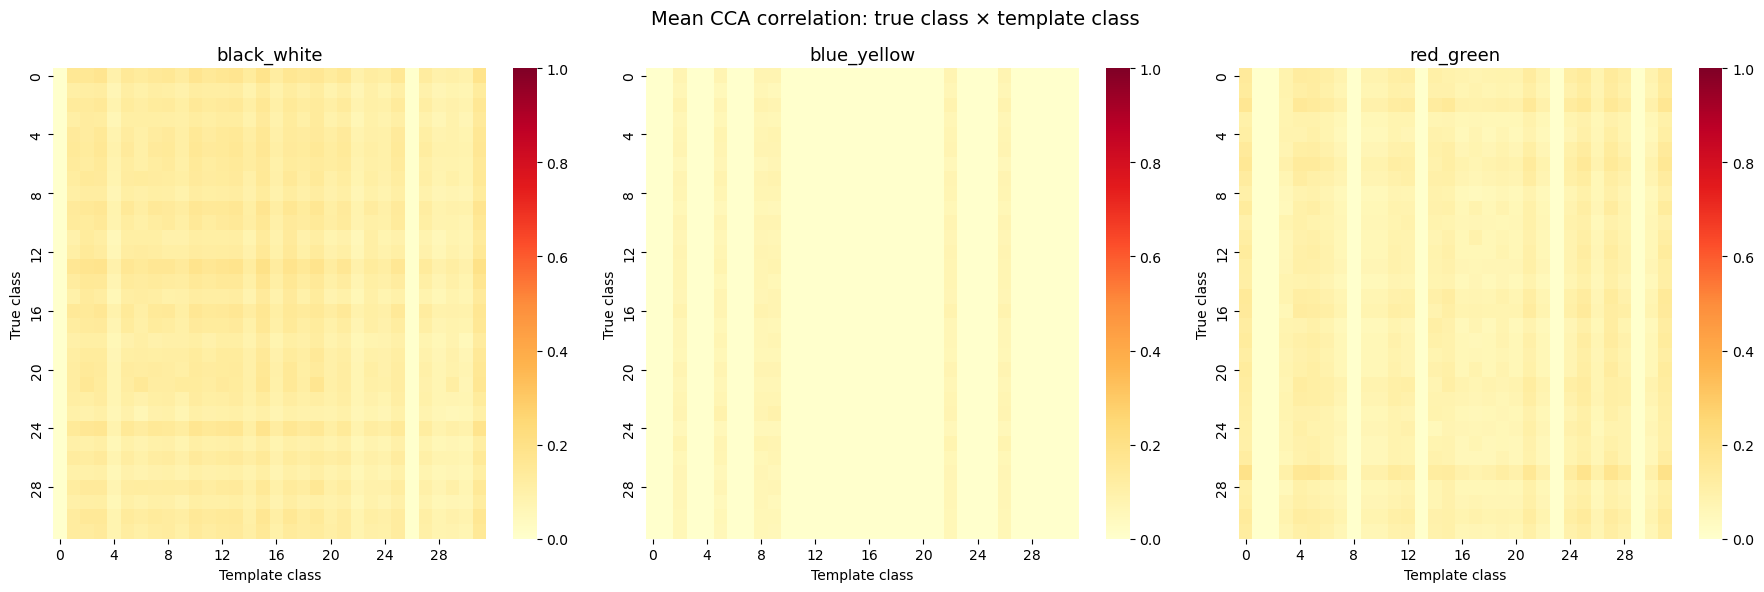

In [9]:
# Heatmap 1: CCA correlation for each class

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cond_name in zip(axes, data.keys()):
    rho    = data[cond_name]['rho']     # (320, 32)
    labels = data[cond_name]['labels']  # (320,)

    # クラスごとの平均相関係数行列 (32, 32)
    mean_rho = np.zeros((32, 32))
    for cls in range(32):
        idxs = np.where(labels == cls)[0]
        mean_rho[cls] = rho[idxs].mean(axis=0)

    sns.heatmap(
        mean_rho,
        ax=ax,
        cmap='YlOrRd',
        vmin=0, vmax=1,
        xticklabels=4,
        yticklabels=4,
        cbar=True,
    )
    ax.set_title(cond_name, fontsize=13)
    ax.set_xlabel('Template class')
    ax.set_ylabel('True class')

fig.suptitle('Mean CCA correlation: true class × template class', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_cca_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

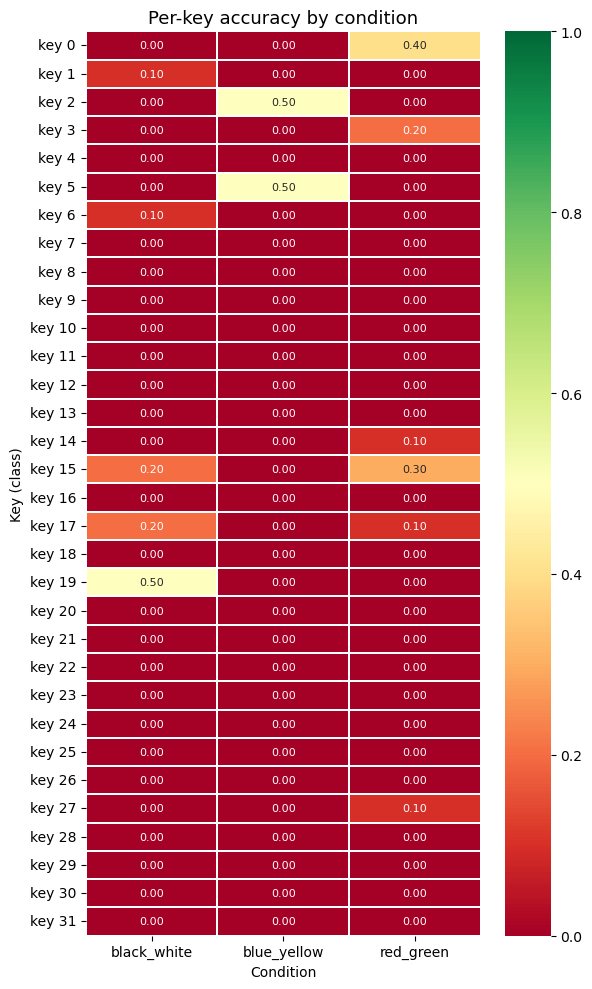

In [10]:
# Heatmap 2: Per-key accuracy by condition

per_class_acc = np.zeros((32, 3))
cond_names    = list(data.keys())

for j, cond_name in enumerate(cond_names):
    labels = data[cond_name]['labels']
    pred   = data[cond_name]['predicted']
    for cls in range(32):
        mask = labels == cls
        per_class_acc[cls, j] = np.mean(pred[mask] == labels[mask])

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(
    per_class_acc,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    xticklabels=cond_names,
    yticklabels=[f'key {i}' for i in range(32)],
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3,
)
ax.set_title('Per-key accuracy by condition', fontsize=13)
ax.set_xlabel('Condition')
ax.set_ylabel('Key (class)')
plt.tight_layout()
plt.savefig('heatmap_accuracy_per_key.png', dpi=150, bbox_inches='tight')
plt.show()

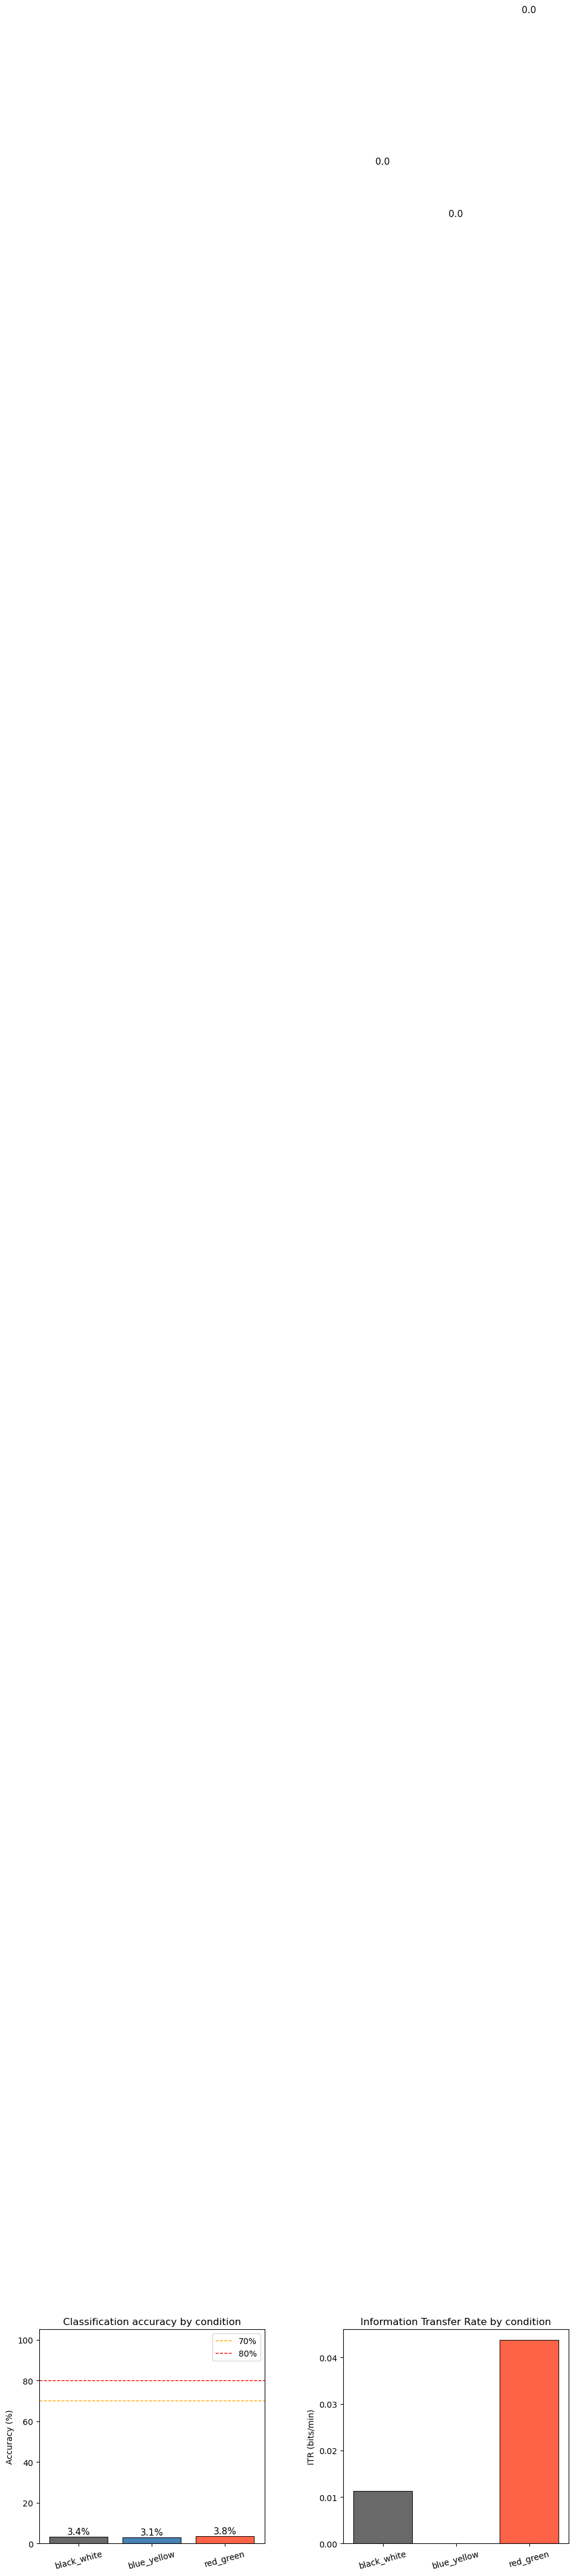

In [11]:
# Accuracy & ITR Graph: Compare between each condition
def compute_itr(accuracy, n_class=32, trial_sec=1.2):
    P = np.clip(accuracy, 1e-10, 1 - 1e-10)
    N = n_class
    B = (np.log2(N)
         + P * np.log2(P)
         + (1 - P) * np.log2((1 - P) / (N - 1)))
    return max(B * (60.0 / trial_sec), 0.0)

# Collect Accuracy・ITR
accuracies = [data[c]['accuracy'] * 100        for c in cond_names]
itrs       = [compute_itr(data[c]['accuracy']) for c in cond_names]
bar_colors = ['dimgray', 'steelblue', 'tomato']  # black_white, blue_yellow, red_green

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Accuracy
axes[0].bar(cond_names, accuracies, color=bar_colors, edgecolor='k', linewidth=0.7)
axes[0].axhline(70, color='orange', linestyle='--', linewidth=1, label='70%')
axes[0].axhline(80, color='red',    linestyle='--', linewidth=1, label='80%')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Classification accuracy by condition')
axes[0].set_ylim(0, 105)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

# ITR
axes[1].bar(cond_names, itrs, color=bar_colors, edgecolor='k', linewidth=0.7)
axes[1].set_ylabel('ITR (bits/min)')
axes[1].set_title('Information Transfer Rate by condition')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(itrs):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11)

plt.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.18, wspace=0.35)
plt.savefig('accuracy_itr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Friedman Test
# test null hypothesis: no difference between three conditions
# https://www.geeksforgeeks.org/dsa/friedman-test/

from scipy.stats import friedmanchisquare

# per_class_acc の列が各条件 (32サンプル × 3条件)
stat, p_val = friedmanchisquare(
    per_class_acc[:, 0],
    per_class_acc[:, 1],
    per_class_acc[:, 2],
)

print('=== Friedman Test Result ===')
print(f'  statistic : {stat:.4f}')
print(f'  p-value   : {p_val:.4f}')
print()
if p_val < 0.05:
    print('  → p < 0.05: Significant difference （H0 rejected）')
else:
    print('  → p >= 0.05: No significant difference（H0 proved）')

print()
print('=== CCA correlation in each condition（H1）===')
for cond_name in cond_names:
    rho = data[cond_name]['rho']
    print(f'  {cond_name:<14}: mean={rho.mean():.4f}  std={rho.std():.4f}')

print()
print('=== Conclusion ===')
print(f"{'Condition':<14} {'Accuracy':>10} {'ITR (bits/min)':>15}")
print('-' * 42)
for cond_name, acc, itr in zip(cond_names, accuracies, itrs):
    print(f'{cond_name:<14} {acc:>9.1f}% {itr:>14.1f}')

=== Friedman Test Result ===
  statistic : 2.2286
  p-value   : 0.3281

  → p >= 0.05: No significant difference（H0 proved）

=== CCA correlation in each condition（H1）===
  black_white   : mean=0.1092  std=0.0616
  blue_yellow   : mean=0.0130  std=0.0299
  red_green     : mean=0.0724  std=0.0554

=== Conclusion ===
Condition        Accuracy  ITR (bits/min)
------------------------------------------
black_white          3.4%            0.0
blue_yellow          3.1%            0.0
red_green            3.8%            0.0
